In [1]:
from auxiliary_functions import *

In [2]:
graph = nx.read_gexf("labeled_graph.gexf")
std_threshold = 0.5
NumberOfRandoms = 300

In [3]:
graphs = simplify_graph(graph, std_threshold)

# Generate null models for each subreddit graph
null_models = {}

for subreddit, subreddit_graph in graphs.items():
	# Create multiple randomized versions of each graph for statistical comparison
	null_models[subreddit] = [
		generate_null_model(subreddit_graph) 
		for _ in range(NumberOfRandoms)
	]

In [ ]:
plot_weight_distribution(graphs)

In [4]:
triangles_graph = calculate_triangles_graph(graphs)

In [ ]:
plot_triangle_distribution(graphs, triangles_graph)

In [ ]:
df = number_of_triangles_per_type(graphs, triangles_graph)

df.to_csv('file.csv', index=True)

df

In [5]:
null_triangles = calculate_triangles_null_graph(graphs, null_models)

In [6]:
# IN DEVELOPMENT: NON_BINARY_METRIC

results_nb, distributions_nb = non_binary_metric(triangles_graph, null_triangles)
results_nb

,prod,mean,std,z-score
subreddit,,,,
politics,0.061540,0.013160,0.025596,1.890196
worldnews,0.089190,0.025227,0.027215,2.350246
politicaldiscussion,0.081276,0.027004,0.015284,3.550836
ukpolitics,0.076475,0.020057,0.015136,3.727419
conservative,0.135232,0.014002,0.047584,2.547731
neoliberal,0.083202,0.027632,0.014286,3.889912
politicalhumor,0.098310,0.004490,0.032065,2.925952
canadapolitics,0.128910,0.022495,0.015340,6.937193
neutralpolitics,0.140683,0.081564,0.025155,2.350179


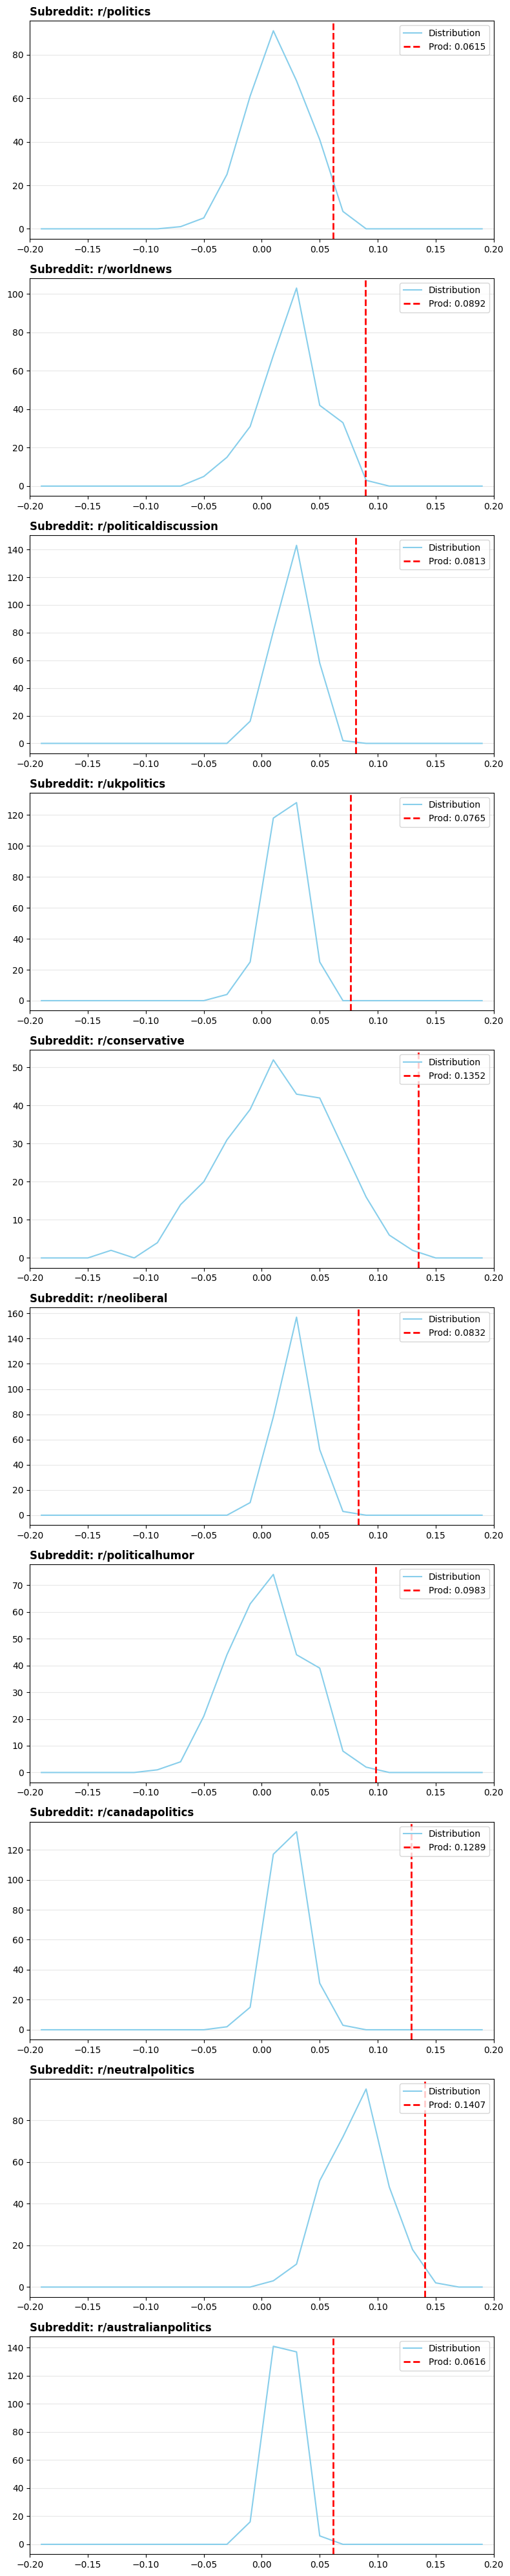

In [11]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_nb)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i, (subreddit, distribution) in enumerate(distributions_nb.items()):
    ax = axes[i]
    
    # 2. Calculate the histogram data manually to plot only the "top points"
    # We use density=True if you want the area to scale, or False for raw counts
    counts, bin_edges = np.histogram(distribution, bins=20, range=(-0.2, 0.2))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. Plot the 'top points' as a step or line plot
    ax.plot(bin_centers, counts, color='skyblue', label='Distribution')
    
    # 4. Plot and highlight the specific 'prod' value
    prod_val = results_nb.loc[subreddit, "prod"]
    ax.axvline(prod_val, color='red', linestyle='--', linewidth=2, label=f'Prod: {prod_val:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.2, 0.2)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

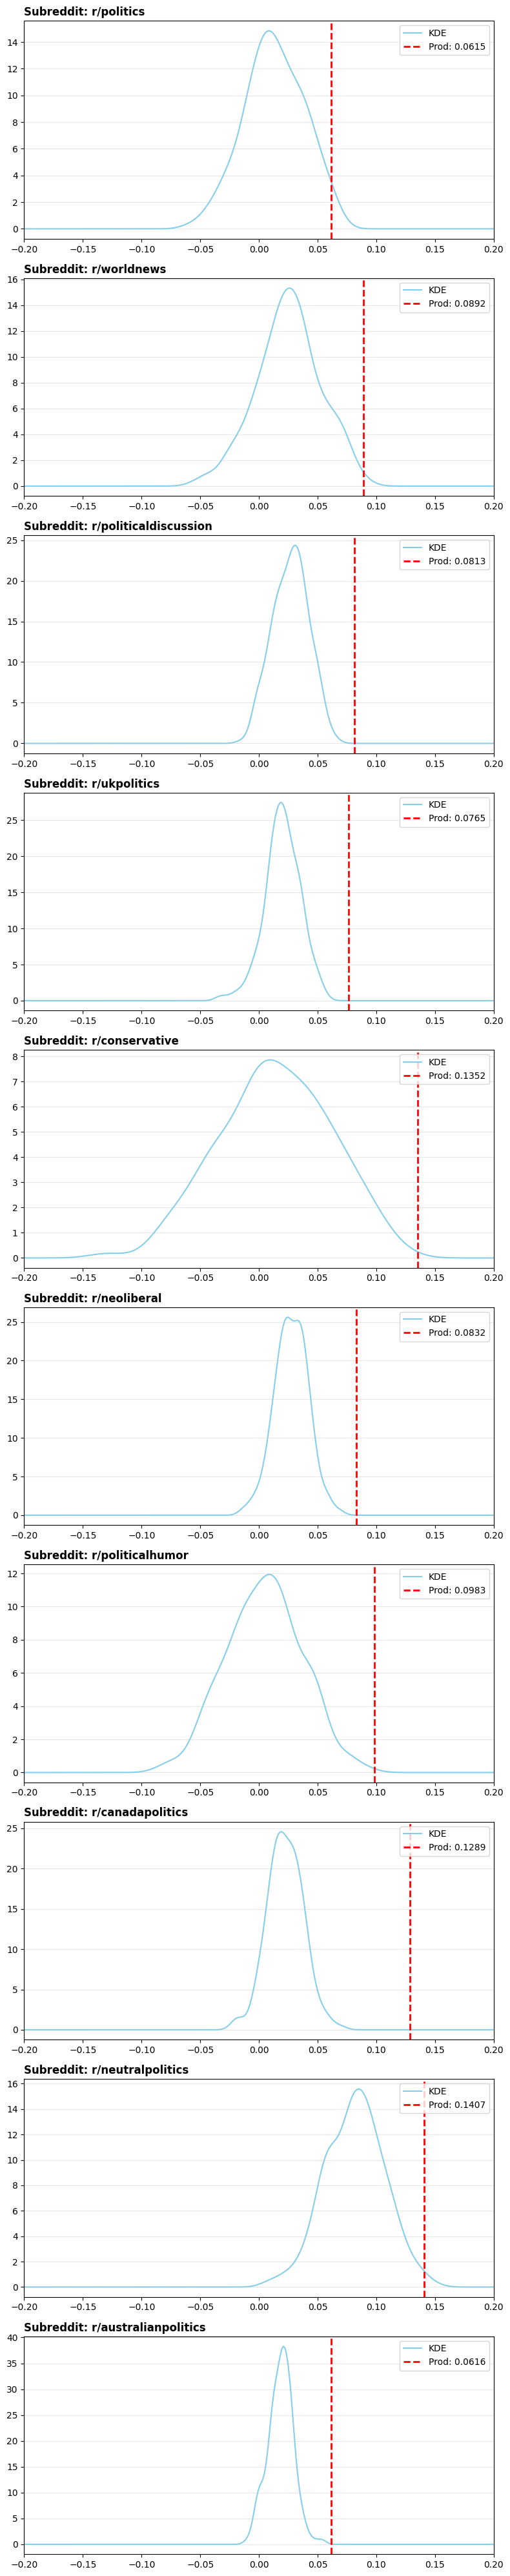

In [13]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_nb)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i, (subreddit, distribution) in enumerate(distributions_nb.items()):
    ax = axes[i]
    
    # 2. Compute a kernel density estimate instead of a raw histogram
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(distribution)
    x_vals = np.linspace(-0.2, 0.2, 300)
    y_vals = kde(x_vals)
    ax.plot(x_vals, y_vals, color='skyblue', label='KDE')
    
    # 4. Plot and highlight the specific 'prod' value
    prod_val = results_nb.loc[subreddit, "prod"]
    ax.axvline(prod_val, color='red', linestyle='--', linewidth=2, label=f'Prod: {prod_val:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.2, 0.2)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
results_b, distributions_b = calculate_balance_metrics(graphs, null_models, NumberOfRandoms)
results_b

In [8]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


with open('distributions_b', 'r') as f:
    distributions_b = json.load(f)
    
    
list_subreddits = ["politics", "worldnews", "politicaldiscussion", "ukpolitics", "conservative", "neoliberal", "politicalhumor", "canadapolitics", "neutralpolitics", "australianpolitics"]
results_b = [0.006191, 0.021197, 0.012899, 0.016738, 0.008455, 0.017590, 0.008977, 0.011335, 0.001428, 0.014914]

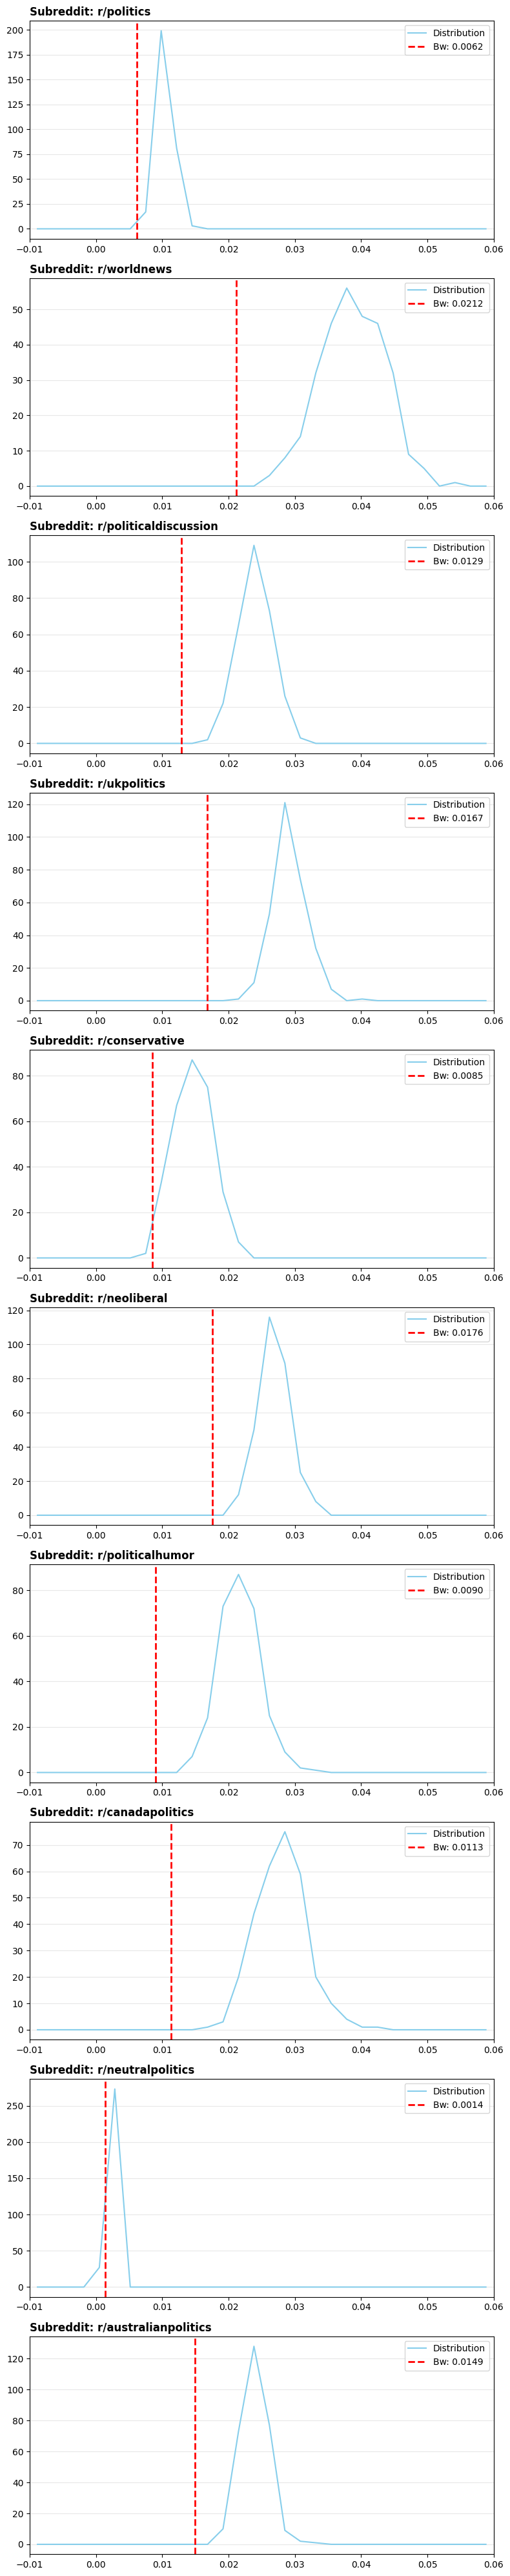

In [9]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_b)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i in range(len(distributions_b)):
    ax = axes[i]
    subreddit = list_subreddits[i]
    distribution = distributions_b[i]
    
    # 2. Calculate the histogram data manually to plot only the "top points"
    # We use density=True if you want the area to scale, or False for raw counts
    counts, bin_edges = np.histogram(distribution, bins=30, range=(-0.01, 0.06))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. Plot the 'top points' as a step or line plot
    ax.plot(bin_centers, counts, color='skyblue', label='Distribution')
    
    # 4. Plot and highlight the specific 'prod' value
    b_w = results_b[i]
    ax.axvline(b_w, color='red', linestyle='--', linewidth=2, label=f'Bw: {b_w:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.01, 0.06)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

[0.01182136648741125, 0.011937632256650735, 0.009711619898900655, 0.010218658028921088, 0.009667534100483353, 0.009082463932821753, 0.009327706570966331, 0.008729806463465727, 0.009487829085454084, 0.00913987067837264, 0.01096422713361519, 0.011443960996639316, 0.009119495046309453, 0.011441757788368324, 0.009185318635094964, 0.010579223285928707, 0.009510123306855491, 0.010878269500687546, 0.009796359703315478, 0.009170876300114863, 0.011046854484180683, 0.010120856971523292, 0.009109358604746778, 0.010236375465607647, 0.009186917781211643, 0.010363127248595255, 0.008598634245389467, 0.010036519933289773, 0.008026247016635632, 0.011285001818288953, 0.007616560145074801, 0.00788568401248706, 0.008591959460158616, 0.010855536776336078, 0.008448093420551932, 0.010866267075136505, 0.008986791157622135, 0.010971011404323766, 0.00892032669241753, 0.008209568886282256, 0.01044820575715134, 0.009609049038044212, 0.010222935474094336, 0.009357366823375846, 0.010114722309201438, 0.0098830928775

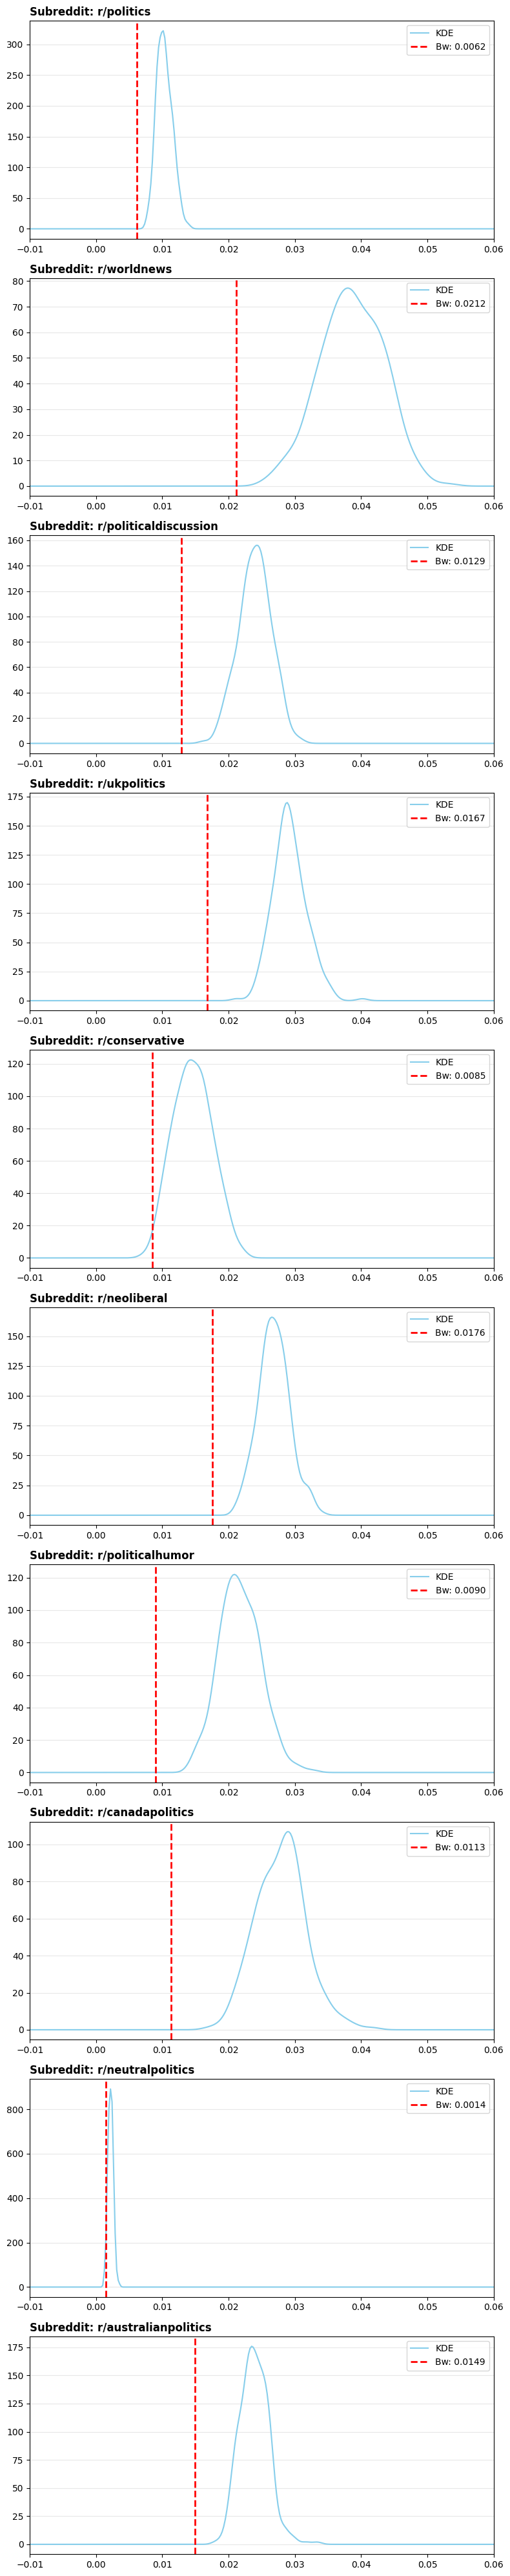

In [ ]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_b)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i in range(len(distributions_b)):
    ax = axes[i]
    subreddit = list_subreddits[i]
    distribution = distributions_b[i]
    
    # 2. Compute a kernel density estimate instead of a raw histogram
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(distribution)
    x_vals = np.linspace(-0.01, 0.06, 300)
    y_vals = kde(x_vals)
    ax.plot(x_vals, y_vals, color='skyblue', label='KDE')

    
    # 3. Plot and highlight the specific 'prod' value
    b_w = results_b[i]
    ax.axvline(b_w, color='red', linestyle='--', linewidth=2, label=f'Bw: {b_w:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.01, 0.06)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
D_distribution = {}
results = []

for idx, (subreddit, triangle_list) in enumerate(triangles_graph.items()):
	# Process real data: compute signed geometric means
	all_triangles_dict = defaultdict(int)
	for triangle in triangle_list:
		val = geo_abs(triangle)
		all_triangles_dict[val] += 1
	
	vals_all, cum_all = prepare_cumulative(all_triangles_dict)
	# Process null models
	null_all_dicts = []
	D_distribution[subreddit] = []
 
	for null_model in null_triangles[subreddit]:
		null_all = defaultdict(int)
		for triangle in null_model:
			val = geo_abs(triangle)
			null_all[val] += 1
		null_all_dicts.append(null_all)
  
		vals_null, cum_null = prepare_cumulative(null_all)
  
		D = kolmogorov(vals_all, cum_all, vals_null, cum_null)
  
		D_distribution[subreddit].append(D)
  
	vals_all_null, cum_all_null = average_null_models(null_all_dicts)
 
	D = kolmogorov(vals_all, cum_all, vals_all_null, cum_all_null)
 
	mean = np.mean(D_distribution[subreddit])
 
	std = np.std(D_distribution[subreddit])

	results.append({
		'subreddit': subreddit,
		'D': D,
		"mean": mean, 
		"std": std,
		"z-score": (D - mean) / std
	})
 
results_df = pd.DataFrame(results).set_index("subreddit")

results_df

In [ ]:
kolmogorov_smirnov(triangles_graph, null_triangles)